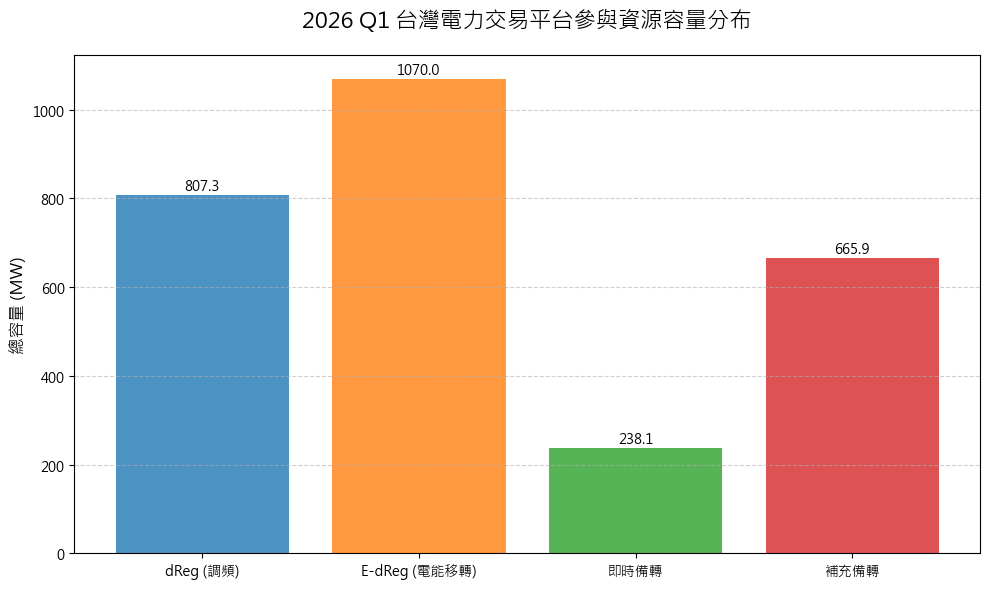

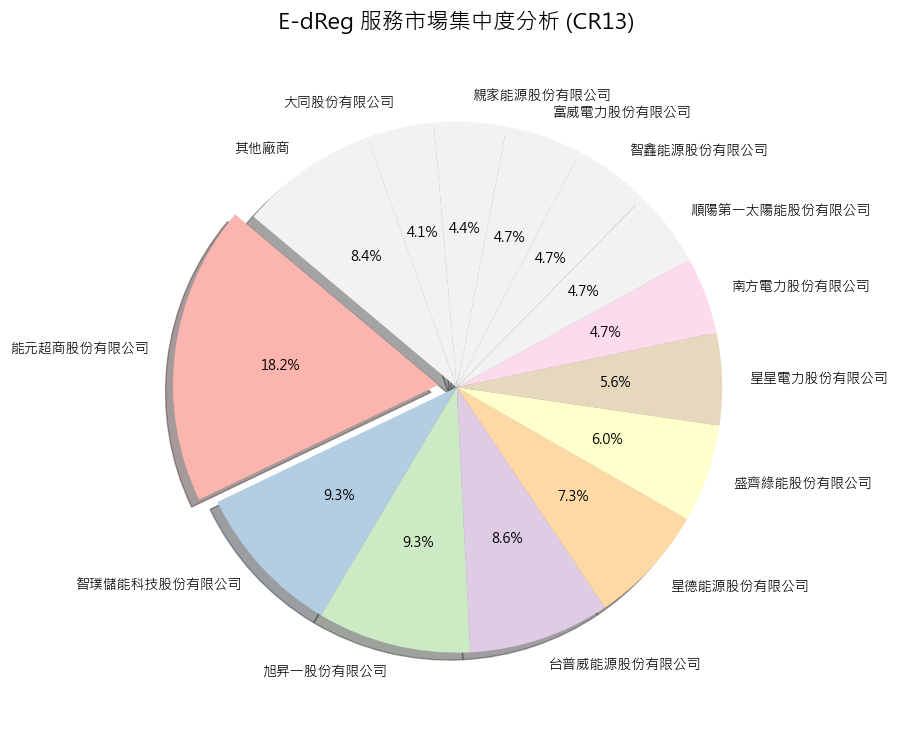

--- 數據統計結果 ---
E-dReg 總建置容量: 1070.00 MW
前五大廠商 (CR5) 合計佔比: 91.58%


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib

# 1. 解決圖表中文顯示問題
matplotlib.rc('font', family='Microsoft JhengHei') 

# 2. 設定你的 Excel 檔案路徑
file_path = r'C:\臺大雲端\氣候政治\台電交易平台資料.xlsx'

try:
    # 3. 讀取與清理數據
    # 讀取 Excel 檔案，並指定從第 2 列開始讀取 (skiprows=1)，以避開受損標題
    df = pd.read_excel(file_path, skiprows=0)
    
    # 檢查並清理空行
    df = df.dropna(subset=['公司名稱'])

    # 欄位轉數值 (根據你提供的欄位名稱)
    cols = ['調頻備轉容量', '電能移轉複合動', '即時備轉容量', '補充備轉容量']
    for col in cols:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    # 4. 圖表一：各項商品總量分布
    plt.figure(figsize=(10, 6))
    totals = df[cols].sum()
    labels = ['dReg (調頻)', 'E-dReg (電能移轉)', '即時備轉', '補充備轉']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    bars = plt.bar(labels, totals, color=colors, alpha=0.8)
    plt.title('2026 Q1 台灣電力交易平台參與資源容量分布', fontsize=16, pad=20)
    plt.ylabel('總容量 (MW)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    # 數值標註
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval:.1f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.savefig('market_hierarchy_large_text_0.png', dpi=300)
    plt.show()

    # 5. 圖表二：E-dReg 廠商市場集中度 (CR5)
    vendor_shares = df.groupby('公司名稱')['電能移轉複合動'].sum().sort_values(ascending=False)
    total_edreg = vendor_shares.sum()

    top5 = vendor_shares.head(13)
    others_sum = vendor_shares.iloc[13:].sum()
    pie_data = pd.concat([top5, pd.Series({'其他廠商': others_sum})])

    plt.figure(figsize=(9, 9))
    explode = [0.07] + [0] * (len(pie_data) - 1)
    plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=140, 
            colors=plt.cm.Pastel1(range(len(pie_data))), explode=explode, shadow=True)
    plt.title('E-dReg 服務市場集中度分析 (CR13)', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

    # 輸出數據
    print(f"--- 數據統計結果 ---")
    print(f"E-dReg 總建置容量: {total_edreg:.2f} MW")
    print(f"前五大廠商 (CR5) 合計佔比: {(top5.sum()/total_edreg)*100:.2f}%")

except Exception as e:
    print(f"讀取檔案失敗：{e}")
    print("請確認是否已安裝 openpyxl (指令: pip install openpyxl)")

In [7]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


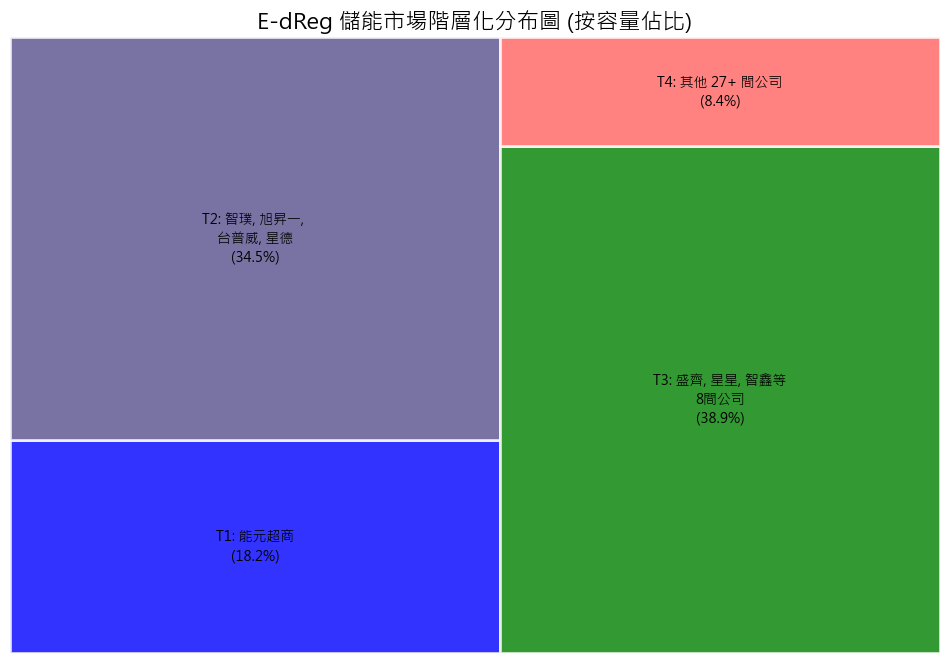

In [4]:
import matplotlib.pyplot as plt
import squarify # pip install squarify

# 準備數據
labels = [
    "T1: 能元超商\n(18.2%)", 
    "T2: 智璞, 旭昇一, \n台普威, 星德\n(34.5%)", 
    "T3: 盛齊, 星星, 智鑫等\n8間公司\n(38.9%)", 
    "T4: 其他 27+ 間公司\n(8.4%)"
]
sizes = [18.2, 34.5, 38.9, 8.4]
colors = ['blue', '#58508d', 'green', '#ff6361']

plt.figure(figsize=(12, 8))
squarify.plot(sizes=sizes, label=labels, color=colors, alpha=0.8, edgecolor="white", linewidth=2)

plt.title("E-dReg 儲能市場階層化分布圖 (按容量佔比)", fontsize=16)
plt.axis('off')
plt.show()

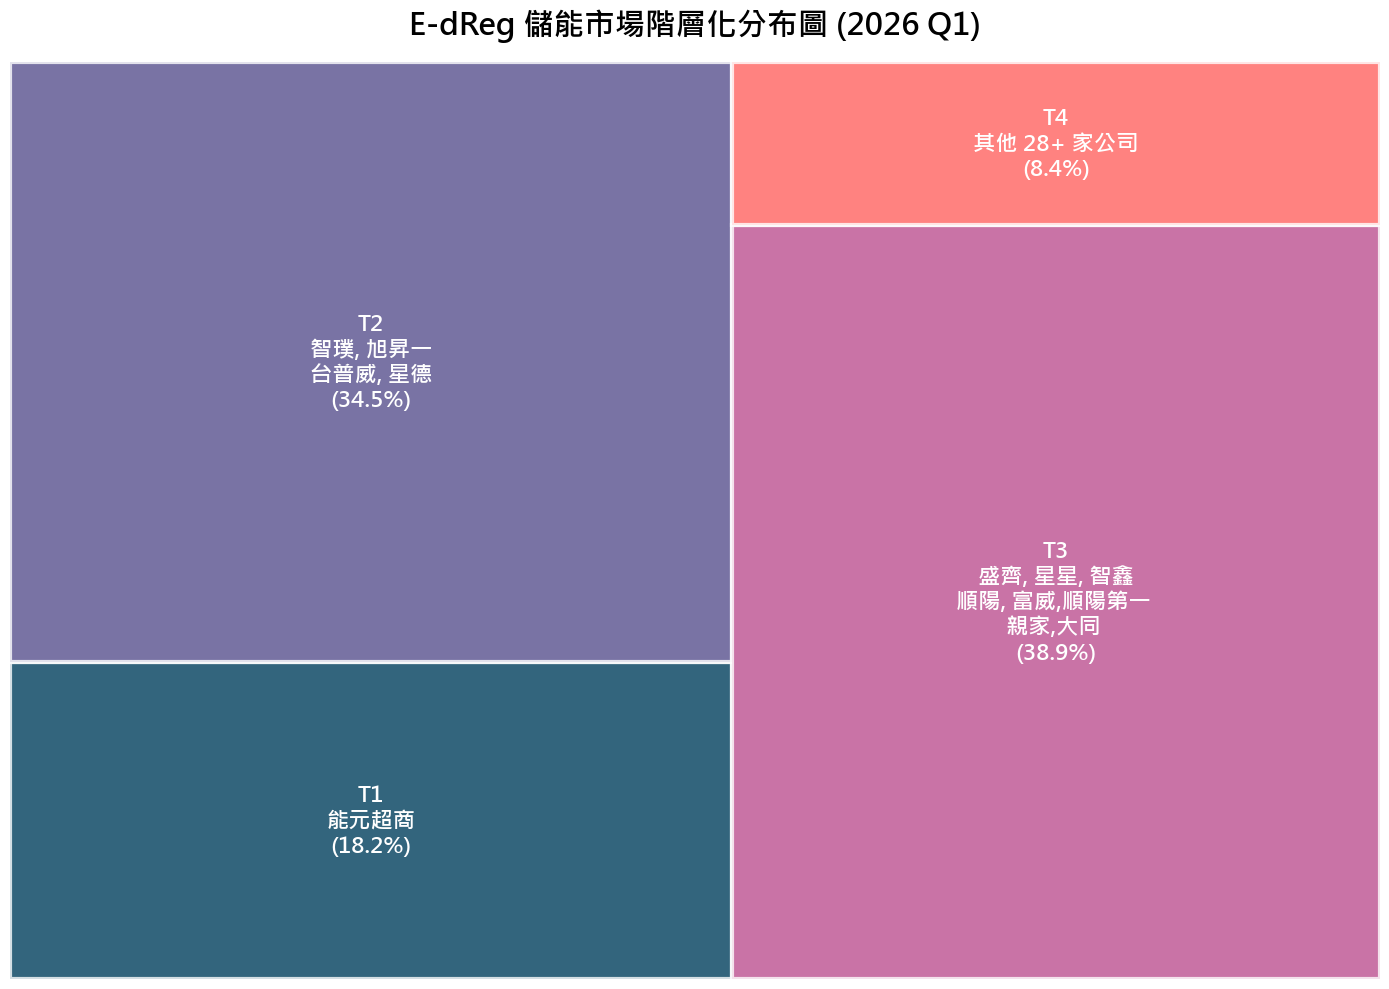

In [8]:
import matplotlib.pyplot as plt
import squarify
import matplotlib

# 1. 解決中文顯示問題
matplotlib.rc('font', family='Microsoft JhengHei') 

# 2. 準備階層數據
# T1: 領導者 / T2: 核心競爭圈 / T3: 中型參與者 / T4: 碎片化尾端
labels = [
    "T1\n能元超商\n(18.2%)", 
    "T2\n智璞, 旭昇一\n台普威, 星德\n(34.5%)", 
    "T3\n盛齊, 星星, 智鑫\n順陽, 富威,順陽第一 \n親家,大同 \n(38.9%)", 

    "T4\n其他 28+ 家公司\n(8.4%)"
]
sizes = [18.2, 34.5, 38.9, 8.4]
colors = ['#003f5c', '#58508d', '#bc5090', '#ff6361']

# 3. 繪圖
plt.figure(figsize=(14, 10)) # 加大畫布

# 調整 squarify 繪圖，並設定文字屬性
# text_kwargs 用來統一加大字體
squarify.plot(sizes=sizes, label=labels, color=colors, alpha=0.8, 
              edgecolor="white", linewidth=3, 
              text_kwargs={'fontsize': 16, 'weight': 'bold', 'color': 'white'})

# 4. 標題與細節設定
plt.title("E-dReg 儲能市場階層化分布圖 (2026 Q1)", fontsize=22, pad=20, weight='bold')
plt.axis('off')

# 儲存高解析度圖表
plt.tight_layout()
plt.savefig('market_hierarchy_large_text.png', dpi=300)
plt.show()